In [9]:
#importing essential libraries.
import pandas as pd
import requests

# Official NASA Power API for daily point data
url = "https://power.larc.nasa.gov/api/temporal/daily/point"

query_params = {
    "parameters": "T2M,WS2M,ALLSKY_SFC_SW_DWN",  # Temperature, Wind Speed, Solar Radiation
    "community": "RE",  # Renewable Energy community
    "longitude": "30.52",   # Longitude
    "latitude": "50.45",   # Latitude
    "start": "20250101",  # Start date (YYYYMMDD)
    "end": "20250131",    # End date (Full year of 2025 data)
    "format": "JSON",     # Request response in JSON format
}

response = requests.get(url, params=query_params)

if response.status_code == 200:
    data = response.json()
    
    # Extract the core parameters from the nested NASA JSON structure
    records = data["properties"]["parameter"]
    df = pd.DataFrame(records)
    
    # # Convert the JSON records directly into a Pandas DataFrame
    df.to_csv("nasa_kyiv_data.csv")
    print("Saved 'nasa_kyiv_data.csv' file successfully!")
else:
    print(f"Failed! Server responded with code: {response.status_code}")

Saved 'nasa_kyiv_data.csv' file successfully!


In [10]:
#Data preprocessing and cleaning
import pandas as pd

# Load csv file
df = pd.read_csv("nasa_kyiv_data.csv")
df.head()

## Rename columns from NASA technical codes to human-readable names
df = df.rename(columns={
    'Unnamed: 0': 'Date', 
    'T2M': 'Temperature',  
    'WS2M': 'Wind_Speed',   
    'ALLSKY_SFC_SW_DWN': 'Solar_Radiation' 
})

# Converting the Date column into a proper Python datetime format
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d', errors='coerce')

df.head()

,Date,Temperature,Wind_Speed,Solar_Radiation
0,2025-01-01,0.57,4.37,1.1592
1,2025-01-02,0.51,5.09,1.2336
2,2025-01-03,-1.28,2.06,0.4968
3,2025-01-04,-2.46,5.41,0.7829
4,2025-01-05,-5.94,3.39,1.2955


In [12]:
#Thermodynamic simulation logic( main Theme in this project.

def calculate_system_performance(row, people_count=10):
    temp = row['Temperature']
    wind = row['Wind_Speed']
    solar = row['Solar_Radiation']
    
    # 1. Thermal Modeling: Building Heat Load Calculation
    # Base load is set to 20kW. Demand increases by 1.5kW for every degree below 18°C.
    # Higher wind speeds increase heat loss, while human body heat provides a small offset.
    base_load = 20 
    temp_effect = max(0, (18 - temp) * 1.5) 
    wind_effect = wind * 0.5
    human_offset = people_count * 0.1
    
    heating_load = max(0, base_load + temp_effect + wind_effect - human_offset)
    
    # Coefficient of Performance (COP) Calculation
    if temp > 0:
        conventional_cop = 3.5 + (temp * 0.05)
        dual_pump_cop = 4.0 + (temp * 0.04)
    else:

        conventional_cop = max(1.0, 2.5 + (temp * 0.15)) 
        dual_pump_cop = max(1.8, 3.2 + (temp * 0.06)) 
        
    
    if solar > 0:
        dual_pump_cop += (solar * 0.001)

    return pd.Series([heating_load, conventional_cop, dual_pump_cop])


df[['Heating_Load_kW', 'Conventional_COP', 'Dual_Pump_COP']] = df.apply(
    lambda row: calculate_system_performance(row, people_count=10), axis=1
)

print( 'output and new columns')
df[['Temperature', 'Heating_Load_kW', 'Conventional_COP', 'Dual_Pump_COP']].head()

output and new columns


,Temperature,Heating_Load_kW,Conventional_COP,Dual_Pump_COP
0,0.57,47.330,3.5285,4.023959
1,0.51,47.780,3.5255,4.021634
2,-1.28,48.950,2.3080,3.123697
3,-2.46,52.395,2.1310,3.053183
4,-5.94,56.605,1.6090,2.844896


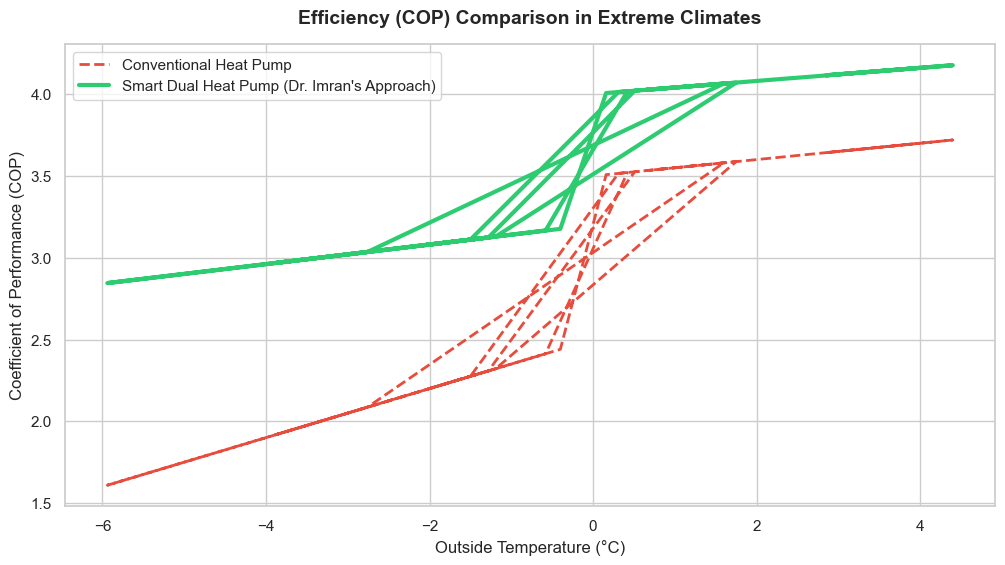

Saved the 1st graph 'cop_comparison_plot.png' successfully 


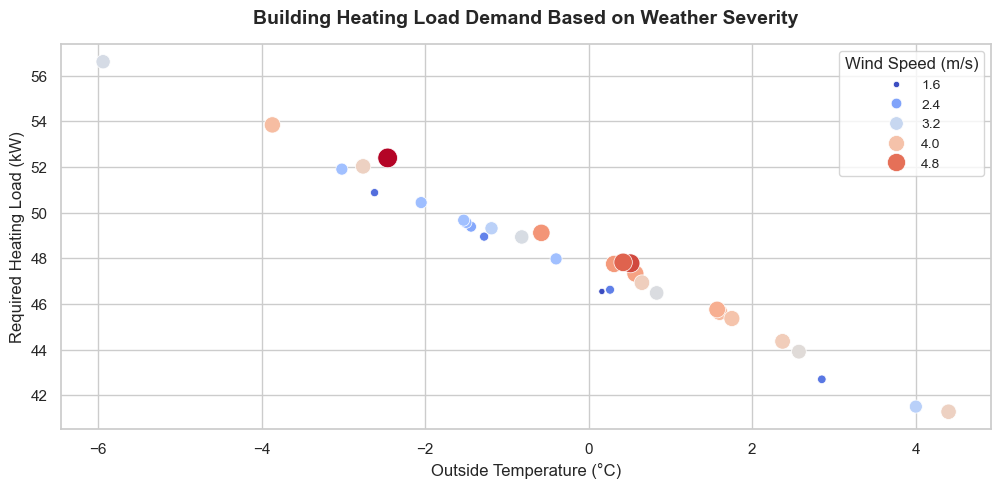

Saved the 2nd graph 'heating_load_plot.png' successfully 


In [14]:
#Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

#Graph labeling, titling, pointing.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.plot(df['Temperature'], df['Conventional_COP'], color='#e74c3c', label='Conventional Heat Pump', linewidth=2, linestyle='--')
plt.plot(df['Temperature'], df['Dual_Pump_COP'], color='#2ecc71', label='Smart Dual Heat Pump (Dr. Imran\'s Approach)', linewidth=3)
plt.title('Efficiency (COP) Comparison in Extreme Climates', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Outside Temperature (°C)', fontsize=12)
plt.ylabel('Coefficient of Performance (COP)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')

#saving plot image.
plt.savefig('cop_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved the 1st graph 'cop_comparison_plot.png' successfully ")

#plot : 2
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x='Temperature', y='Heating_Load_kW', hue='Wind_Speed', palette='coolwarm', size='Wind_Speed', sizes=(20, 200))
plt.title('Building Heating Load Demand Based on Weather Severity', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Outside Temperature (°C)', fontsize=12)
plt.ylabel('Required Heating Load (kW)', fontsize=12)
plt.legend(title='Wind Speed (m/s)', fontsize=10)

# Save graph
plt.savefig('heating_load_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved the 2nd graph 'heating_load_plot.png' successfully ")